<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# get updated github content
!git clone https://github.com/SiyuL2025/math_629_final.git
!cd /content/math_629_final && git pull

fatal: destination path 'math_629_final' already exists and is not an empty directory.
Already up to date.


In [29]:
# import data
import sys
sys.path.append('./math_629_final')

import BTC_ETH_pipeline

Device: cuda
  Transformer LOB  |  feature_set = 'raw'
Feature set : RAW BTC LOB  (60 features, no PCA, no market)
X shape : (99902, 60)  |  y shape : (99902,)
Label dist — Down:31,426  Flat:37,159  Up:31,317
Train samples : 79,892  |  Test samples : 19,952
Class weights (down/flat/up) : [1.02  0.944 1.042]
Model params : 106,627  |  Input features : 60

--- Training ---


/tmp/ipykernel_1048/704262861.py:139: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.0854 | Val Loss 1.0613 | Val Acc 0.4434
Ep   2/30 | Train Loss 1.0610 | Val Loss 1.0314 | Val Acc 0.4651
Ep   3/30 | Train Loss 1.0401 | Val Loss 1.0138 | Val Acc 0.4847
Ep   4/30 | Train Loss 1.0289 | Val Loss 1.0061 | Val Acc 0.4949
Ep   5/30 | Train Loss 1.0225 | Val Loss 1.0012 | Val Acc 0.4968
Ep   6/30 | Train Loss 1.0180 | Val Loss 0.9989 | Val Acc 0.4981
Ep   7/30 | Train Loss 1.0139 | Val Loss 0.9962 | Val Acc 0.4988
Ep   8/30 | Train Loss 1.0107 | Val Loss 0.9965 | Val Acc 0.4992
Ep   9/30 | Train Loss 1.0073 | Val Loss 0.9960 | Val Acc 0.4984
Ep  10/30 | Train Loss 1.0034 | Val Loss 0.9950 | Val Acc 0.4982
Ep  11/30 | Train Loss 1.0003 | Val Loss 0.9972 | Val Acc 0.4983
Ep  12/30 | Train Loss 0.9970 | Val Loss 0.9974 | Val Acc 0.4976
Ep  13/30 | Train Loss 0.9925 | Val Loss 1.0015 | Val Acc 0.4933
Ep  14/30 | Train Loss 0.9894 | Val Loss 1.0028 | Val Acc 0.4931
Early stop at epoch 14. Best val acc: 0.4992

--- Evaluation ---
              precision  

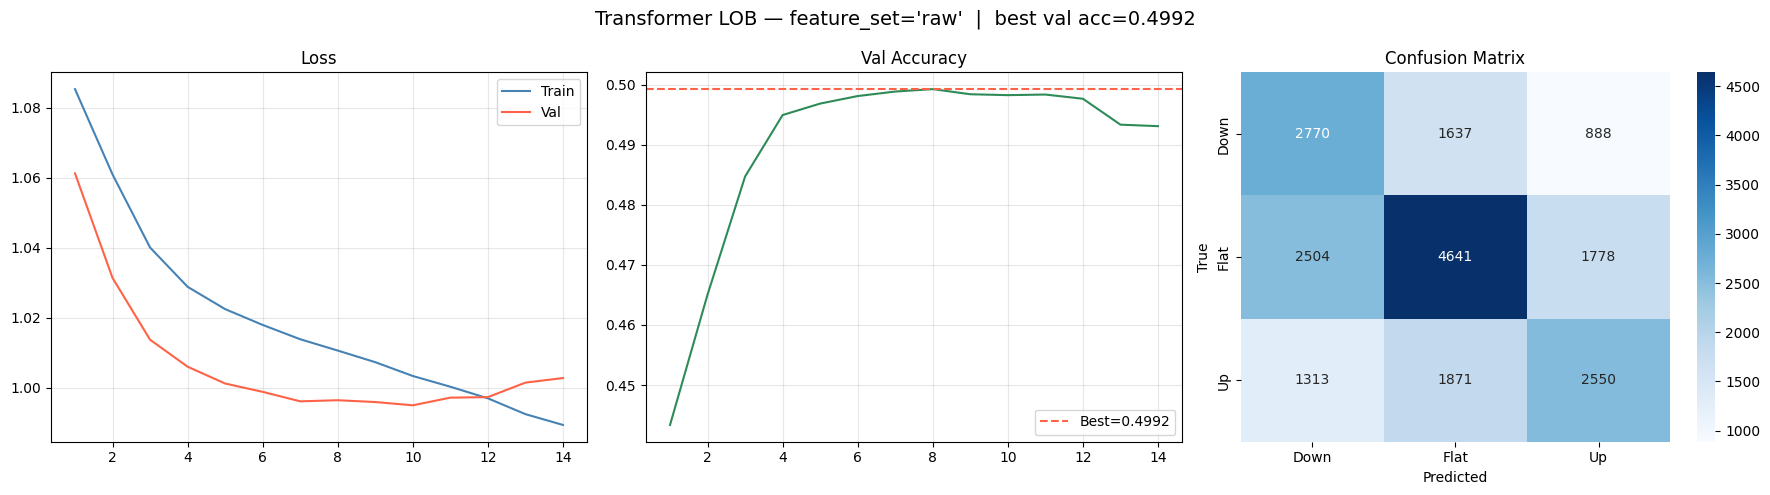

In [30]:
import math, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ╔══════════════════════════════════════════════════════════════════╗
# ║              ★  CHOOSE YOUR INPUTS HERE  ★                      ║
# ║                                                                  ║
# ║  FEATURE_SET:                                                    ║
# ║    "full"  → PCA components + ALL market features                ║
# ║              (BTC + ETH + cross-asset, i.e. X_final)            ║
# ║    "pca"   → PCA components only  (no market features)           ║
# ║    "raw"   → original 60 BTC LOB features (no PCA, no market)   ║
# ╚══════════════════════════════════════════════════════════════════╝
FEATURE_SET = "raw"    # ← change me: "full" | "pca" | "raw"

# ── Config ────────────────────────────────────────────────────────────────────
SEED       = 42
SEQ_LEN    = 30
D_MODEL    = 64
N_HEADS    = 4
N_LAYERS   = 3
D_FF       = 128
DROPOUT    = 0.1
BATCH_SIZE = 256
EPOCHS     = 30
LR         = 3e-4
PATIENCE   = 6

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Feature Selection
# ══════════════════════════════════════════════════════════════════════════════
def select_features(feature_set: str):
    """
    "full" → X_final  (PCA cols + BTC market + ETH market + cross-asset features)
    "pca"  → PCA columns only  (columns starting with 'pca_')
    "raw"  → 60 original BTC LOB features from df  (no PCA, no market)
    """
    if feature_set == "full":
        print("Feature set : FULL  (PCA + BTC/ETH market state + cross-asset)")
        X = BTC_ETH_pipeline.X_final.values.astype(np.float32)

    elif feature_set == "pca":
        pca_cols = [c for c in BTC_ETH_pipeline.X_final.columns if c.startswith("pca_")]
        print(f"Feature set : PCA only  ({len(pca_cols)} components)")
        X = BTC_ETH_pipeline.X_final[pca_cols].values.astype(np.float32)

    elif feature_set == "raw":
        lob_cols = []
        for i in range(15):
            lob_cols += [f"bids_distance_{i}", f"asks_distance_{i}",
                         f"bids_notional_{i}", f"asks_notional_{i}"]
        print(f"Feature set : RAW BTC LOB  ({len(lob_cols)} features, no PCA, no market)")
        X = BTC_ETH_pipeline.df[lob_cols].values.astype(np.float32)

    else:
        raise ValueError(f"Unknown feature_set '{feature_set}'. Choose 'full', 'pca', or 'raw'.")

    y = (BTC_ETH_pipeline.Y_final.values + 1).astype(np.int64)   # {-1, 0, 1} → {0, 1, 2}
    print(f"X shape : {X.shape}  |  y shape : {y.shape}")
    print(f"Label dist — Down:{(y==0).sum():,}  Flat:{(y==1).sum():,}  Up:{(y==2).sum():,}")
    return X, y


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Dataset & DataLoaders
# ══════════════════════════════════════════════════════════════════════════════
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


def build_loaders(X, y):
    """Chronological 80/20 split → normalise → sliding-window DataLoaders."""
    split  = int(len(X) * 0.8)
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X[:split])
    X_te   = scaler.transform(X[split:])
    y_tr, y_te = y[:split], y[split:]

    counts  = np.bincount(y_tr, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples : {len(train_loader.dataset):,}  |  "
          f"Test samples : {len(test_loader.dataset):,}")
    print(f"Class weights (down/flat/up) : {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Model
# ══════════════════════════════════════════════════════════════════════════════
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class LOBTransformer(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.proj    = nn.Linear(n_features, D_MODEL)
        self.pos_enc = PositionalEncoding(D_MODEL, dropout=DROPOUT)
        enc_layer    = nn.TransformerEncoderLayer(
            D_MODEL, N_HEADS, D_FF, DROPOUT,
            activation="gelu", batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))
        self.head    = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, 3)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.pos_enc(self.proj(x))    # (B, T, D_MODEL)
        x = self.encoder(x).mean(dim=1)   # mean-pool over time
        return self.head(x)


def build_model(n_features):
    model    = LOBTransformer(n_features).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model params : {n_params:,}  |  Input features : {n_features}")
    return model


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Training
# ══════════════════════════════════════════════════════════════════════════════
def train(model, train_loader, test_loader, class_w):
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train(); running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        model.eval(); vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(Xb)
                vloss  += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total   += len(yb)
        val_loss = vloss / total
        val_acc  = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Ep {epoch:3d}/{EPOCHS} | "
              f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc, patience_cnt = val_acc, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
                break

    model.load_state_dict(best_state)
    return history, best_acc


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Evaluation
# ══════════════════════════════════════════════════════════════════════════════
def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            all_preds.append(model(Xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))
    return y_pred, y_true


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Plots
# ══════════════════════════════════════════════════════════════════════════════
def plot_results(history, y_pred, y_true, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Transformer LOB — {title}", fontsize=14)

    ep = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    best = max(history["val_acc"])
    axes[1].plot(ep, history["val_acc"], color="seagreen")
    axes[1].axhline(best, color="tomato", linestyle="--", label=f"Best={best:.4f}")
    axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
                xticklabels=["Down", "Flat", "Up"],
                yticklabels=["Down", "Flat", "Up"])
    axes[2].set_title("Confusion Matrix")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Full Pipeline
# ══════════════════════════════════════════════════════════════════════════════
def run_transformer(feature_set: str):
    """
    End-to-end pipeline.

    Parameters
    ----------
    feature_set : "full" | "pca" | "raw"

    Reads from notebook scope
    -------------------------
    X_final      — DataFrame produced by the data cell (PCA + market features)
    Y_final      — Series of labels {-1, 0, 1}
    df           — raw DataFrame (needed for "raw" feature set)
    """
    print("=" * 60)
    print(f"  Transformer LOB  |  feature_set = '{feature_set}'")
    print("=" * 60)

    X, y                        = select_features(feature_set)
    train_ld, test_ld, class_w  = build_loaders(X, y)
    model                       = build_model(n_features=X.shape[1])

    print("\n--- Training ---")
    history, best_acc = train(model, train_ld, test_ld, class_w)

    print("\n--- Evaluation ---")
    y_pred, y_true = evaluate(model, test_ld)

    plot_results(history, y_pred, y_true,
                 title=f"feature_set='{feature_set}'  |  best val acc={best_acc:.4f}")
    return model, history


# ══════════════════════════════════════════════════════════════════════════════
#  ★  ENTRY POINT
#     • Single run  : change FEATURE_SET at the top, run the cell
#     • Compare all : uncomment the three lines below
# ══════════════════════════════════════════════════════════════════════════════
model, history = run_transformer(FEATURE_SET)

# --- compare all three feature sets ---
# m1, h1 = run_transformer("full")
# m2, h2 = run_transformer("pca")
# m3, h3 = run_transformer("raw")

  Transformer LOB  |  feature_set = 'raw'
Feature set : RAW BTC LOB  (60 features, no PCA, no market)
X shape : (99902, 60)  |  y shape : (99902,)
Label dist — Down:31,426  Flat:37,159  Up:31,317
Train samples : 79,892  |  Test samples : 19,952
Class weights (down/flat/up) : [1.02  0.944 1.042]
Model params : 106,627  |  Input features : 60

--- Training ---


/tmp/ipykernel_1048/704262861.py:139: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.0824 | Val Loss 1.0595 | Val Acc 0.4450
Ep   2/30 | Train Loss 1.0611 | Val Loss 1.0422 | Val Acc 0.4636
Ep   3/30 | Train Loss 1.0464 | Val Loss 1.0219 | Val Acc 0.4816
Ep   4/30 | Train Loss 1.0339 | Val Loss 1.0096 | Val Acc 0.4952
Ep   5/30 | Train Loss 1.0255 | Val Loss 1.0037 | Val Acc 0.4989
Ep   6/30 | Train Loss 1.0188 | Val Loss 0.9992 | Val Acc 0.5043
Ep   7/30 | Train Loss 1.0136 | Val Loss 0.9963 | Val Acc 0.5042
Ep   8/30 | Train Loss 1.0089 | Val Loss 0.9962 | Val Acc 0.5031
Ep   9/30 | Train Loss 1.0043 | Val Loss 0.9952 | Val Acc 0.5072
Ep  10/30 | Train Loss 1.0009 | Val Loss 0.9949 | Val Acc 0.5072
Ep  11/30 | Train Loss 0.9966 | Val Loss 0.9994 | Val Acc 0.5063
Ep  12/30 | Train Loss 0.9921 | Val Loss 0.9980 | Val Acc 0.5059
Ep  13/30 | Train Loss 0.9893 | Val Loss 0.9986 | Val Acc 0.5050
Ep  14/30 | Train Loss 0.9844 | Val Loss 1.0025 | Val Acc 0.5012
Ep  15/30 | Train Loss 0.9799 | Val Loss 1.0017 | Val Acc 0.5017
Ep  16/30 | Train Loss 0.

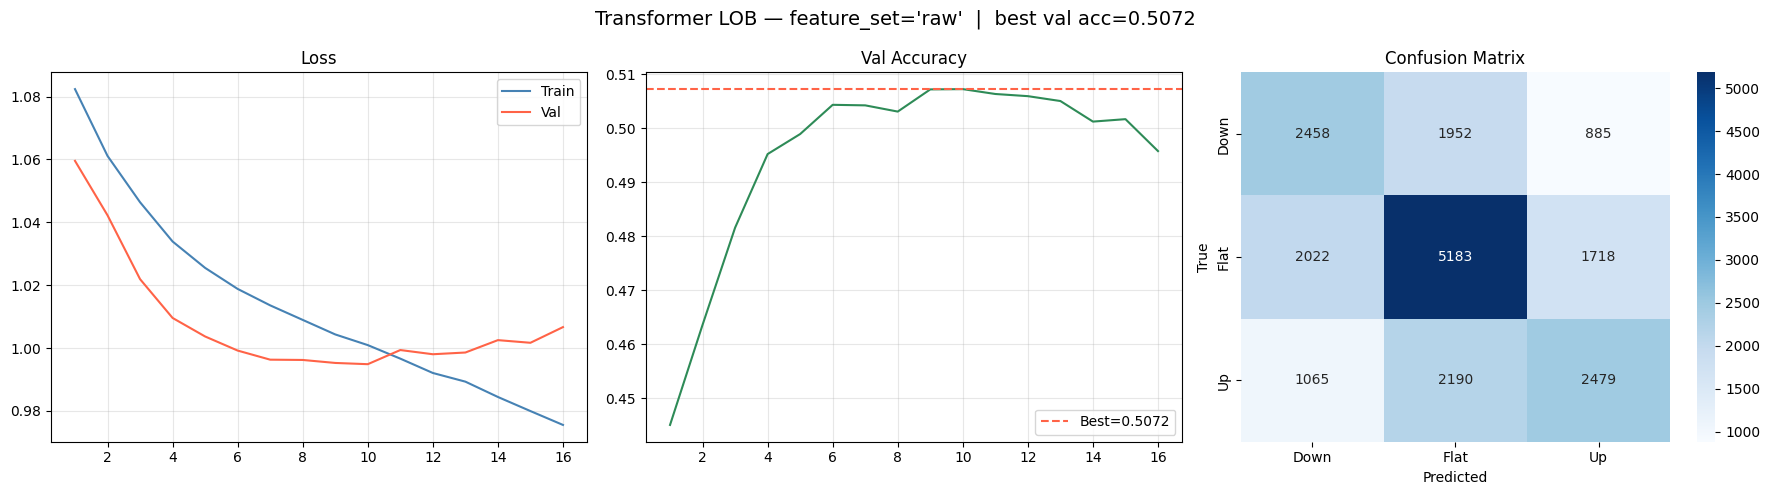

In [31]:
# pca model
FEATURE_SET = "raw"
model, history = run_transformer(FEATURE_SET)

  Transformer LOB  |  feature_set = 'full'
Feature set : FULL  (PCA + BTC/ETH market state + cross-asset)
X shape : (99902, 45)  |  y shape : (99902,)
Label dist — Down:31,426  Flat:37,159  Up:31,317
Train samples : 79,892  |  Test samples : 19,952
Class weights (down/flat/up) : [1.02  0.944 1.042]
Model params : 105,667  |  Input features : 45

--- Training ---


/tmp/ipykernel_1048/704262861.py:139: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.0792 | Val Loss 1.0514 | Val Acc 0.4688
Ep   2/30 | Train Loss 1.0475 | Val Loss 1.0125 | Val Acc 0.4870
Ep   3/30 | Train Loss 1.0218 | Val Loss 0.9892 | Val Acc 0.5057
Ep   4/30 | Train Loss 1.0085 | Val Loss 0.9802 | Val Acc 0.5128
Ep   5/30 | Train Loss 1.0030 | Val Loss 0.9772 | Val Acc 0.5161
Ep   6/30 | Train Loss 0.9982 | Val Loss 0.9763 | Val Acc 0.5178
Ep   7/30 | Train Loss 0.9941 | Val Loss 0.9757 | Val Acc 0.5182
Ep   8/30 | Train Loss 0.9917 | Val Loss 0.9762 | Val Acc 0.5181
Ep   9/30 | Train Loss 0.9887 | Val Loss 0.9769 | Val Acc 0.5170
Ep  10/30 | Train Loss 0.9847 | Val Loss 0.9772 | Val Acc 0.5164
Ep  11/30 | Train Loss 0.9807 | Val Loss 0.9796 | Val Acc 0.5157
Ep  12/30 | Train Loss 0.9775 | Val Loss 0.9805 | Val Acc 0.5143
Ep  13/30 | Train Loss 0.9740 | Val Loss 0.9828 | Val Acc 0.5122
Early stop at epoch 13. Best val acc: 0.5182

--- Evaluation ---
              precision    recall  f1-score   support

        Down       0.44      0.49  

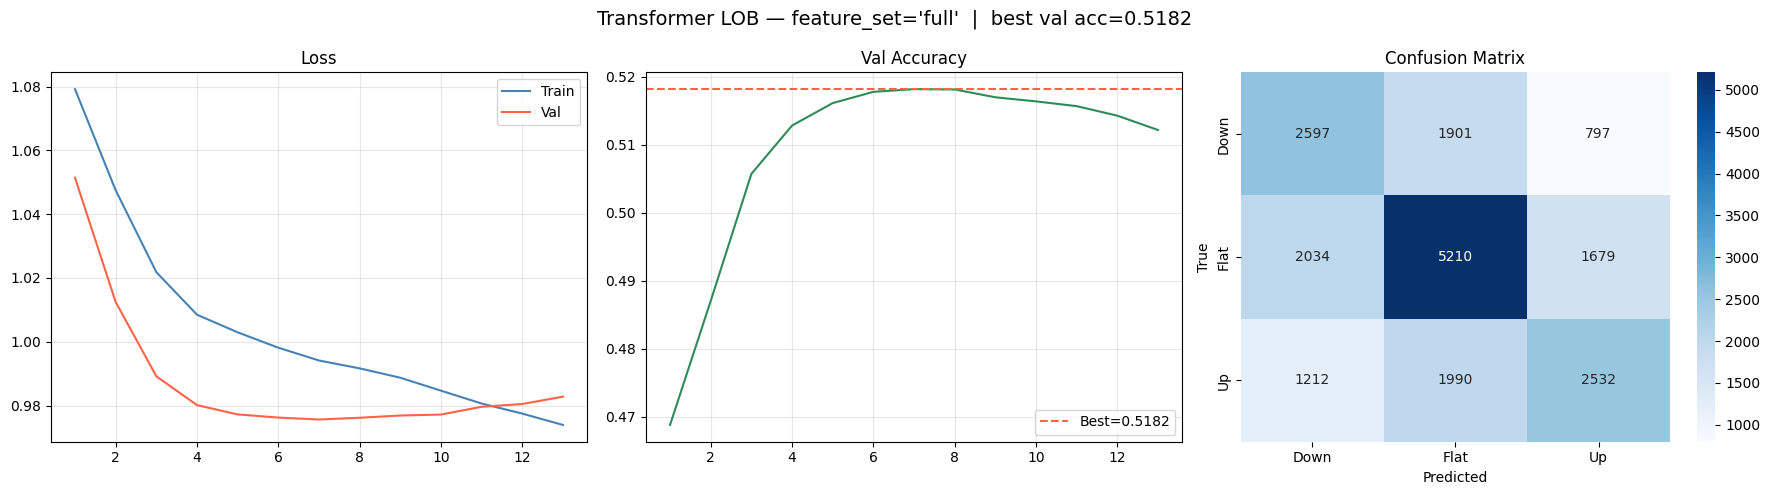

In [32]:
# pca model plus market facotrs
FEATURE_SET = "full"
model, history = run_transformer(FEATURE_SET)